# Loss Functions and Backpropagation
##### What are Loss Functions ?
  - **What Are Loss Functions?**
    - Quantify the difference between the predicted output of a model and the actual target value
    - Guide the training process by providing a metric to minimize during optimization
    - Role in Neural Network
      - `Error Management`: Evaluate the accurace of prediction
      - `Feedback for Optimization`: Provides gradients for weight updates via backpropagation
  
 ### Understanding Loss Function
  Common Types of Loss Function
  ##### Mean Square Error (MSE)
   - Commonly used for regression tasks
   - Penalizes larger errors moe heacily than smaller once
  
  ##### Cross-Entropy Loss
   - Used for classfication tasks
   - Measures the difference between true labels and predicted probabilities

---

# Backpropagation
#### what is Backpropagation ?
  - Process of computing gradients for each weight and bias in a neural network, enabling optimization algorithms (like gradient descent) to minimize the loss function
  - #### Steps in Backpropagation
    - **Forward Pass:** Compute the output and loss for the current weights
    - **Backward Pass:** Calculates the gradients of the loss with respect to each parameter
    - **Weight Update:** Use the gradients to update parameters
  
  - #### Key Concepts
    - **Gradients:** The rate of change of the loss with respect to a parameter
    - **Gradient Descent:** An optimization algorithm that minimizes the loss by updating parameter in the direction of negative gradient


In [1]:
import numpy as np

# Mean Squared Error(MSE) loss
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Binary Cross-Entropy (BCE) loss
def binary_cross_entropy_loss(y_true, y_pred):
    y_pred = np.clip(y_pred,1e-15, 1-1e-15)
    return -np.mean(y_true * np.log(y_pred)+(1-y_true)* np.log(1-y_pred))



In [2]:
# Example Data
y_true = np.array([1,0,1,1])
y_pred = np.array([0.9, 0.2, 0.8, 0.7])



In [3]:
# Calculate loss
mse = mse_loss(y_true, y_pred)
bce = binary_cross_entropy_loss(y_true, y_pred)

print(f"MSE LOSS:{mse:.4f}")
print(f"Binary Cross-Entropy Loss:{bce:.4f}")

MSE LOSS:0.0450
Binary Cross-Entropy Loss:0.2271


In [4]:
# Derivative of MSE Loss
def mse_gradient(y_true, y_pred):
    return 2*(y_pred-y_true)/len(y_true)

In [5]:
# Dericative od BCE Loss
def bce_gradient(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1-1e-15)
    return (y_pred - y_true)/(y_pred*(1-y_pred))

In [6]:
# Calculate Gradients
grad_mse = mse_gradient(y_true, y_pred)
grad_bce = bce_gradient(y_true, y_pred)

print(f"MSE Gradients:{grad_mse}")
print(f"BCE Gradients:{grad_bce}")

MSE Gradients:[-0.05  0.1  -0.1  -0.15]
BCE Gradients:[-1.11111111  1.25       -1.25       -1.42857143]


In [7]:
# Visualising these effects
import matplotlib.pyplot as plt

# Define prediction and true labels
predictions = np.linspace(0,1,100)
true_label = 1

In [8]:
# Compute losses
mse_losses = [(true_label - p)**2 for p in predictions]
bce_losses = [-true_label * np.log(max(p, 1e-15))-(1- true_label) * np.log(max(1-p, 1e-15)) for p in predictions]

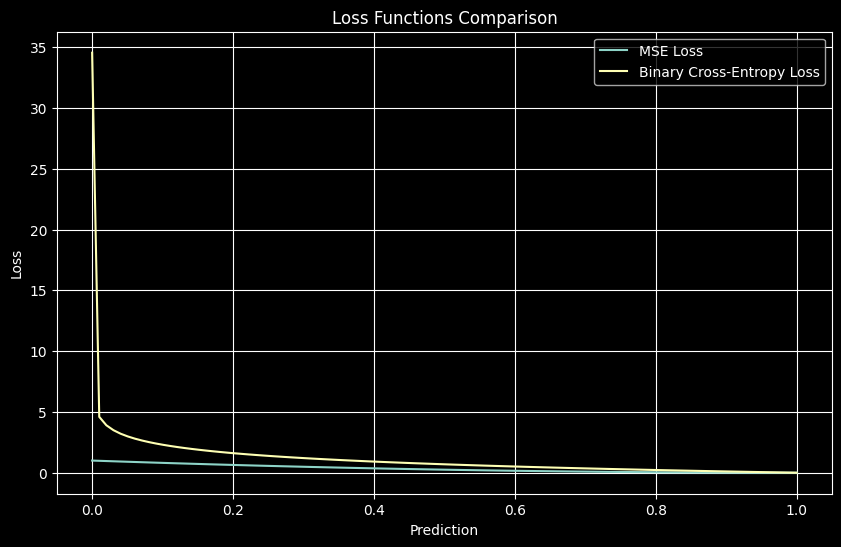

In [10]:
# PLot
plt.figure(figsize=(10,6))
plt.plot(predictions, mse_losses, label = "MSE Loss")
plt.plot(predictions, bce_losses, label = "Binary Cross-Entropy Loss")
plt.title('Loss Functions Comparison')
plt.xlabel('Prediction')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()